In [1]:
%load_ext autoreload
%autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from jax.scipy import stats

from approximator import LikelihoodApproximator
from priors import truncated_normal_rvs
from mcmc import model_nle, warmup, inference_loop_multiple_chains
from plots import create_profile_likelihood_plot, create_pushforward_plot_rdmc
from rdmc import rdmc_experiment_simple, rdmc_prior
from density import rdmc_approx_likelihood, get_pdf

jax.config.update("jax_enable_x64", True)

INFO:2025-12-12 17:21:46,566:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=5000, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = 500 # np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([rdmc_prior, simulator_fun], meta_fn=meta)

In [3]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

test_data = simulator.sample(1)
# test_data["x"][..., 0] *= 1000
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

0.834


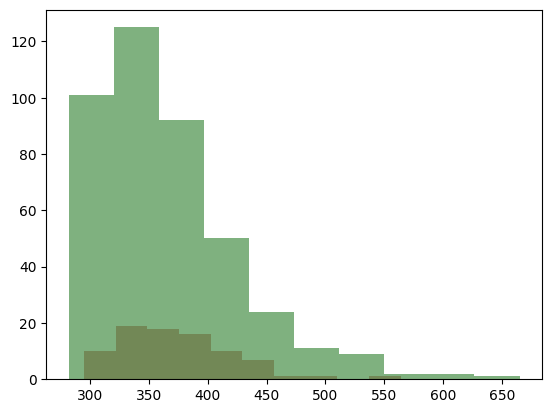

In [4]:
rt, choice = test_data["x"][..., 0], test_data["x"][..., 1]

fig, ax = plt.subplots()

ax.hist(rt[choice==0], alpha = 0.5, color="indianred")
ax.hist(rt[choice==1], alpha = 0.5, color="darkgreen")

print(np.mean(choice))

plt.show()

In [5]:
approximator = keras.saving.load_model("outputs/rdmc_single/flow_matching/epochs=20/mlp_depth=3/mlp_residual=true/mlp_width=5/checkpoints/model.keras")
approximator.inference_network.integrate_kwargs["steps"] = 10
approximator.inference_network.integrate_kwargs["method"] = "rk45"

In [6]:
def modify_test_data(test_data, idx, acc):
    x = test_data["x"]
    rt = x[..., 0]
    choice = x[..., 1]
    if acc == 1:
        v_c = test_data["v_c_intercept"] + test_data["v_c_slope"]
        s = test_data["s_true"]
    else:
        v_c = test_data["v_c_intercept"]
        s = 4.0


    test_data_new = test_data | dict(x=np.expand_dims(rt[choice==idx], 0), v_c=v_c, s=s)
    del test_data_new["v_c_intercept"]
    del test_data_new["v_c_slope"]
    del test_data_new["s_true"]

    return test_data_new

In [7]:
def approx_pdf(data, t_max=1500.0, dt=5.0):
    # 1. Adjust RT
    rt = data["x"][0]
    decision_time = rt - data["t0"][0]
    
    params = dict(
        mu_c=data["v_c"][0],
        A=data["amp"][0],
        alpha=2.0, tau=data["tau"][0], 
        b=data["b"][0], sigma=data["s"][0]
    )

    # 2. Get PDFs for both accumulators
    t_grid, pdf1 = get_pdf(params, t_max, dt)
    
    # 3. Compute CDFs (Cumulative Sum * dt)
    
    # 4. Find index corresponding to decision time
    # We use soft interpolation or nearest index. For simplicity, nearest:
    idx = jnp.round(decision_time / dt).astype(int) - 1
    
    # Safety clipping for indices
    idx = jnp.clip(idx, 0, len(t_grid)-1)

    # Likelihood if choice == 0
    dens = pdf1[idx]
    
    # Avoid log(0)
    return jnp.log(jnp.maximum(dens, 1e-10))

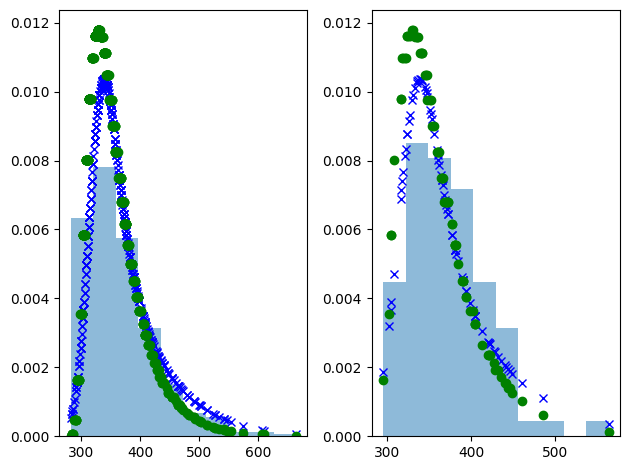

In [8]:
test_data_1 = modify_test_data(test_data, 1, 1)

prob_nle = np.exp(approximator.log_prob(test_data_1)).squeeze()
prob_approx = np.exp(approx_pdf(test_data_1))

fig, (ax1, ax2) = plt.subplots(1, 2)

rt = test_data_1["x"][0]
ax1.hist(rt, density=True, alpha=0.5)
ax1.plot(rt, prob_nle, "x", color="blue")
ax1.plot(rt, prob_approx, "o", color="green")

test_data_0 = modify_test_data(test_data, 0, 1)
rt = test_data_0["x"][0]

prob_nle = np.exp(approximator.log_prob(test_data_0)).squeeze()
prob_approx = np.exp(approx_pdf(test_data_0))

ax2.hist(rt, density=True, alpha=0.5)
ax2.plot(rt, prob_nle, "x", color="blue")
ax2.plot(rt, prob_approx, "o", color="green")

fig.tight_layout()

In [9]:
def approx_likelihood(data):
    rt, choice = data["x"][0, :, 0], data["x"][0, :, 1]
    s_false = 4.0
    a_shape = 2.0
    return rdmc_approx_likelihood(
        rt,
        choice,
        data["v_c_intercept"].squeeze(),
        data["v_c_slope"].squeeze(),
        data["amp"].squeeze(),
        data["tau"].squeeze(),
        data["s_true"].squeeze(),
        s_false,
        data["b"].squeeze(),
        data["t0"].squeeze(),
        a_shape,
        2500.0,
        5.0,
    )

approx_likelihood(test_data).sum()

Array(-2862.73335973, dtype=float64)

In [10]:
p = approximator.log_prob(modify_test_data(test_data, 0, 1)).squeeze()

In [11]:
ll_approximator = LikelihoodApproximator(approximator)

In [12]:
def nle_likelihood(data):
    def modify_test_data(test_data, acc):
        x = test_data["x"]
        rt = x[..., 0]

        if acc == 1:
            v_c = test_data["v_c_intercept"] + test_data["v_c_slope"]
            s = test_data["s_true"]
        else:
            v_c = test_data["v_c_intercept"]
            s = jnp.array([4.0])[None, :]

        test_data_new = test_data | dict(x=rt, v_c=v_c, s=s)
        del test_data_new["v_c_intercept"]
        del test_data_new["v_c_slope"]
        del test_data_new["s_true"]

        return test_data_new

    choice = data["x"][..., 1].squeeze()

    # print(ll_approximator.approximator.adapter(modify_test_data(data, 1))["inference_conditions"][:, 0, :])
    # print(ll_approximator.approximator.adapter(modify_test_data(data, 0))["inference_conditions"][:, 0, :])

    log_pdf_true, log_sf_true = ll_approximator.log_pdf_sf(modify_test_data(data, 1))
    log_pdf_false, log_sf_false = ll_approximator.log_pdf_sf(modify_test_data(data, 0))

    dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
    dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

    return jnp.where(choice == 1, dens_true, dens_false)
    
nle_likelihood(test_data).sum()

Array(-2842.9048, dtype=float32)

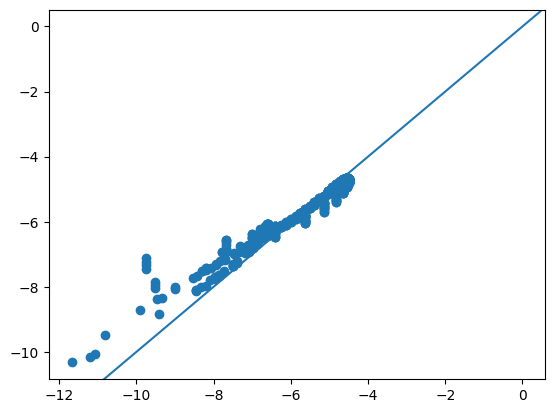

In [13]:
fig, ax = plt.subplots()

ax.scatter(approx_likelihood(test_data), nle_likelihood(test_data))
ax.axline((0, 0), slope=1)

In [14]:
param_names

['v_c_intercept', 'v_c_slope', 'tau', 'amp', 's_true', 'b', 't0']

In [56]:
@jax.jit
def inv_gauss_logpdf(t, mu, lam):

    e = -(lam / (2 * t)) * (t**2 / mu**2 - 2 * t / mu  + 1)

    x = e + 0.5 * jnp.log(lam) - 0.5 * jnp.log(2 * t**3 * jnp.pi)

    return x

@jax.jit
def inv_gauss_logsf(t, mu, lam):
    """https://journal.r-project.org/archive/2016-1/giner-smyth.pdf"""
    mu = mu / lam
    t = t / lam
    r = 1.0 / jnp.sqrt(t)
    a = stats.norm.logcdf(-r * ((t / mu) - 1.0))
    b = 2.0 / mu + stats.norm.logcdf(-r * (t + mu) / mu)
    return jnp.where(jnp.isposinf(t), -jnp.inf, jnp.where(t > 0.0, a + jnp.log1p(-jnp.exp(b - a)), 0.0))

# @jax.jit
def inv_gauss_log_pdf_sf(data):
    rt = data["inference_variables"].squeeze()
    x = jnp.exp(data["inference_conditions"])
    # print(x)

    rt = rt - x[5]
    rt = jnp.maximum(0.0, rt)

    # mu_winner = b/drift_winner
    mu = x[4]/x[0]
    # lam_winner = (b/s_winner)**2
    lam = (x[4]/x[3])**2

    return inv_gauss_logpdf(rt, mu, lam), inv_gauss_logsf(rt, mu, lam)

def create_nle_likelihood_fun(data, approximator):
    def modify_test_data(test_data, acc):
        x = test_data["x"]
        rt = x[..., 0]

        if acc == 1:
            v_c = test_data["v_c_intercept"] + test_data["v_c_slope"]
            s = test_data["s_true"]
        else:
            v_c = test_data["v_c_intercept"]
            s = jnp.array([4.0])[None, :]

        test_data_new = test_data | dict(x=rt, v_c=v_c, s=s)
        del test_data_new["v_c_intercept"]
        del test_data_new["v_c_slope"]
        del test_data_new["s_true"]

        return test_data_new
    
    num_obs = data["num_obs"]

    data = modify_test_data(data, 1)

    data_adapted, ldj = approximator.approximator.adapter(data, strict=False, log_det_jac=True, stage="inference")
    ldj_inference = ldj.get("inference_variables", 0.0)

    # print(data_adapted)

    @jax.jit
    def nle_likelihood_fun(x):
        data_true_copy = data_adapted.copy()
        data_false_copy = data_adapted.copy()

        x_true = jnp.array([jnp.logaddexp(x[0], x[1]), x[2], x[3], x[4], x[5], x[6]]) # ["v_c", "tau", "amp", "s", "b", "t0"]
        x_false = jnp.array([x[0], x[2], x[3], jnp.log(4.0), x[5], x[6]])

        # print(jnp.exp(x_true))
        # print(jnp.exp(x_false))

        # print(data_true_copy["inference_conditions"][:, 0, :])
        # print(data_false_copy["inference_conditions"][:, 0, :])

        data_true_copy["inference_conditions"] = jnp.tile(x_true, (1, num_obs, 1))
        # data_true_copy["inference_conditions"] = x_true
        # data_false_copy["inference_conditions"] = jnp.tile(x_false, (1, num_obs, 1))
        data_false_copy["inference_conditions"] = x_false

        # print(data_true_copy["inference_conditions"][:, 0, :])
        # print(data_false_copy["inference_conditions"][:, 0, :])

        data_true_prepared, log_det_jac_true = approximator._prepare_data_adapted(data_true_copy, ldj_inference, log_det_jac=True)
        # data_false_prepared, log_det_jac_false = approximator._prepare_data_adapted(data_false_copy, ldj_inference, log_det_jac=True)

        # print(data_true_prepared["inference_conditions"][:, 0, :])
        # print(data_false_prepared["inference_conditions"][:, 0, :])
        # print(data_true_prepared["inference_variables"][:, 0, :])

        # print(log_det_jac_true)
        # print(log_det_jac_false)

        choice = data["x"][..., 1].squeeze()

        log_pdf_true, log_sf_true = approximator._log_pdf_sf(data_true_prepared, log_det_jac_true)
        # log_pdf_true, log_sf_true = inv_gauss_log_pdf_sf(data_true_copy)
        # log_pdf_false, log_sf_false = approximator._log_pdf_sf(data_false_prepared, log_det_jac_false)
        log_pdf_false, log_sf_false = inv_gauss_log_pdf_sf(data_false_copy)

        # print(log_pdf_true.squeeze())
        # print(log_pdf_false.squeeze().shape)

        dens_true = log_pdf_true.squeeze() + log_sf_false.squeeze()
        dens_false = log_pdf_false.squeeze() + log_sf_true.squeeze()

        return jnp.where(choice == 1, dens_true, dens_false)

    return nle_likelihood_fun

In [57]:
ll_fun = create_nle_likelihood_fun(test_data, ll_approximator)

In [58]:
prior_draws

array([1.79993712e-01, 4.69979375e-01, 2.69825543e+01, 1.61718161e+01,
       3.65381787e+00, 7.47867517e+01, 2.64891122e+02])

In [59]:
ll_fun(jnp.log(prior_draws)).sum()

Array(-3557.3293048, dtype=float64)

In [60]:
def likelihood(x):
    return ll_fun(x).sum()

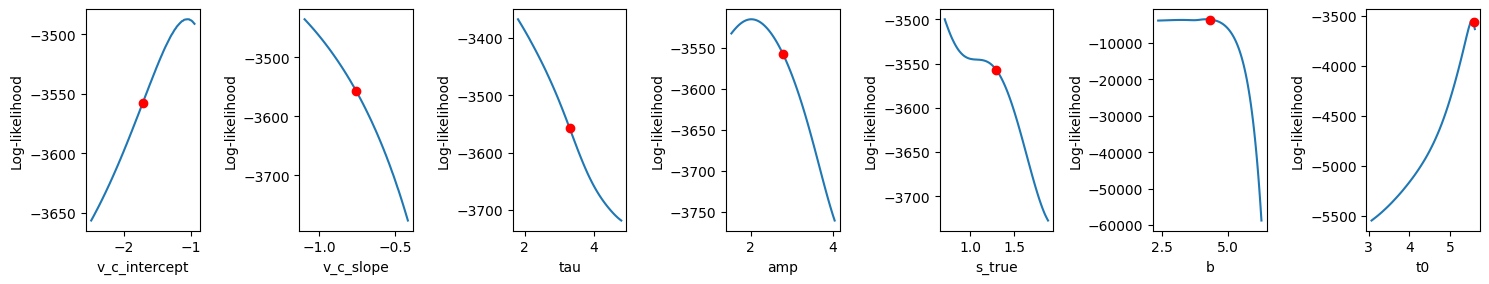

In [62]:
_ = create_profile_likelihood_plot(likelihood, jnp.log(prior_draws), param_names)

In [64]:
init_position = np.array([0.1, 0.5, 50, 20, 4, 75, test_data["x"][..., 0].min() / 2])

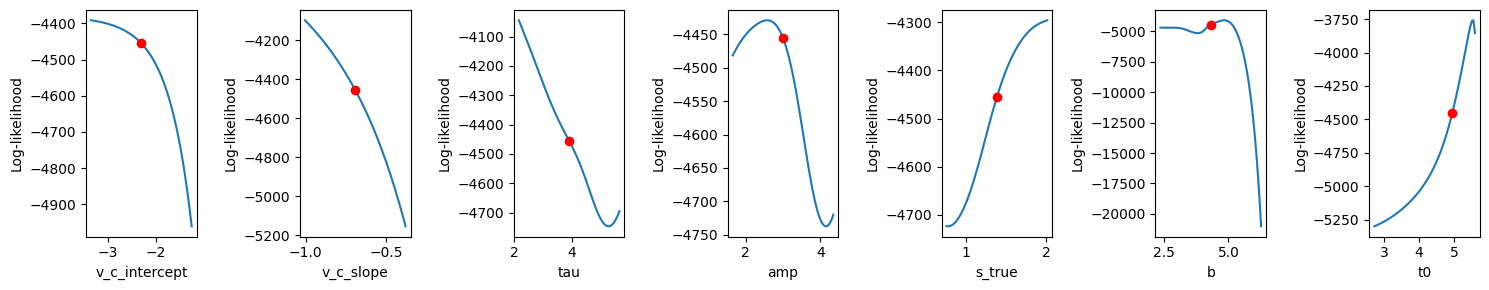

In [65]:
_ = create_profile_likelihood_plot(likelihood, jnp.log(init_position), param_names)

In [66]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

kernel, last_state, warmup_parameters = warmup(
    blackjax.nuts,
    likelihood,
    jnp.log(init_position),
    500,
    warmup_key,
    # target_acceptance_rate=0.9,
    progress_bar=True,
)

Running window adaptation


In [67]:
warmup_parameters

{'step_size': Array(0.12609541, dtype=float64, weak_type=True),
 'inverse_mass_matrix': Array([3.85478090e-03, 5.17152646e+15, 1.01877659e+13, 8.22905004e+14,
        6.70097463e+13, 1.03864037e-02, 4.23535931e-04], dtype=float64)}

In [68]:
for p1, p2, p3 in zip(np.exp(last_state.position), init_position, prior_draws):
    print(p1, p2, p3)

0.7204398026562804 0.1 0.1799937119758308
inf 0.5 0.4699793747526849
0.0 50.0 26.982554338919627
0.0 20.0 16.171816079825447
inf 4.0 3.6538178739746145
75.2457126817166 75.0 74.7867517313577
256.39850302425623 141.4455609467348 264.8911218934696


/tmp/ipykernel_182086/753738943.py:1: RuntimeWarning: overflow encountered in exp
  for p1, p2, p3 in zip(np.exp(last_state.position), init_position, prior_draws):


In [34]:
np.exp(last_state.position)

array([1.42456904e-01, 0.00000000e+00, 4.68459309e-01, 3.35310134e+01,
       2.78780145e+02])

In [ ]:
num_chains = 4

last_states = jax.vmap(lambda x: last_state)(np.arange(num_chains))

trace = inference_loop_multiple_chains(
    rng_key, kernel, last_states, 500, num_chains
)

In [25]:
blackjax.diagnostics.potential_scale_reduction(trace.position)

Array([0.88807757, 1.33452073, 0.94948029, 0.87897033, 0.8825954 ,
       0.90602347, 0.94316805], dtype=float64)

INFO:arviz.preview:arviz_base not installed
INFO:arviz.preview:arviz_stats not installed
INFO:arviz.preview:arviz_plots not installed


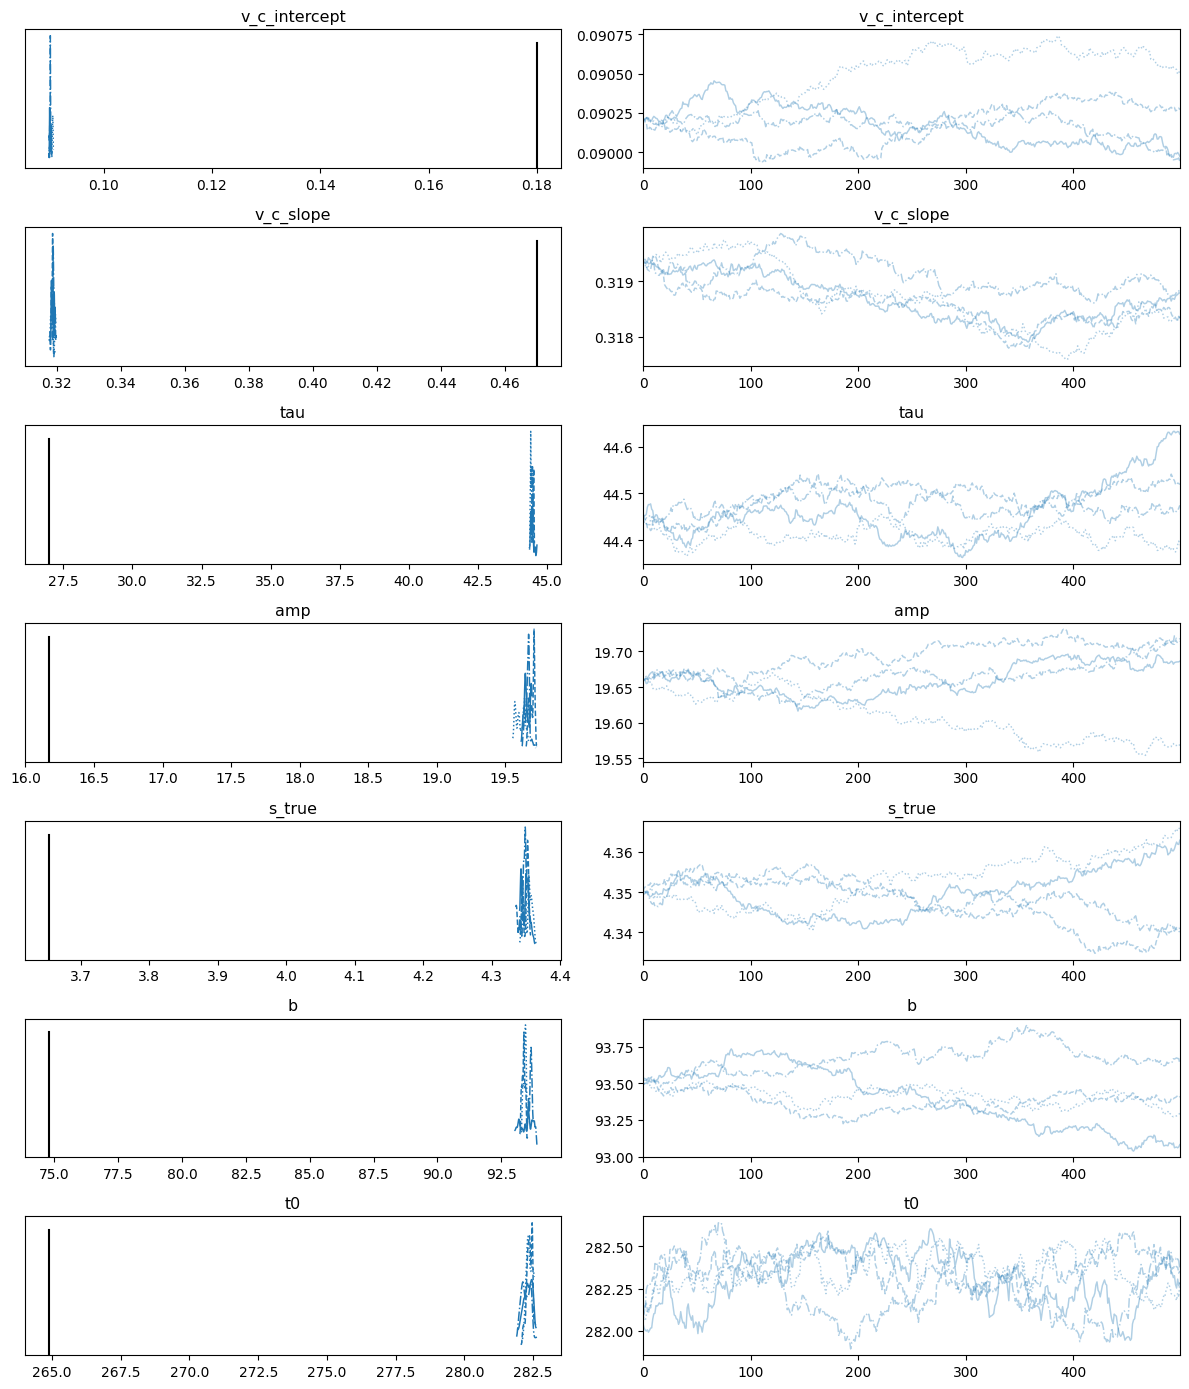

In [26]:
import matplotlib.pyplot as plt
import arviz as az

reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, np.moveaxis(np.exp(trace.position), (0, 1, 2), (2, 1, 0)))})
ax = az.plot_trace(idata)

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()